# Interpretabilidad global y local: SHAP y LIME

Sección 5.3 de la guía. Los valores de Shapley reparten la predicción de cada observación entre las
variables según la teoría de juegos cooperativos: la contribución de una variable es su aporte
marginal promedio sobre todas las coaliciones posibles de las demás. Satisfacen **eficiencia** (las
contribuciones suman la diferencia entre la predicción y el valor base), **simetría** (dos variables
que aportan lo mismo en toda coalición reciben lo mismo) y **aditividad** (la explicación de un
ensamble es la suma de las de sus partes), lo que los hace comparables entre observaciones y
agregables en una importancia global.

Se explican:

* el **mejor modelo de clasificación** y el **mejor de regresión**, elegidos por AUC de validación
  cruzada (no por la prueba);
* **XGBoost de clasificación** siempre, con SHAP y con LIME, como exige la Sección 7.2.

Las explicaciones se calculan sobre la prueba con los modelos finales del capítulo 06/07. Los valores
de las variables están en la escala del preprocesamiento (estandarizados): un valor positivo significa
"por encima de la media de desarrollo".

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
import shap
from src import experimento as ex, finales as fin, preprocesamiento as prep, datos, modelos as mod

pliegues, maestra = ex.consolidar()
conj = datos.cargar_traspaso()
part = prep.preparar_final(conj)
NOMBRES = part.columnas
X_te, y_te = np.asarray(part.X_va), np.asarray(part.y_va).astype(int)
rng = np.random.default_rng(config.SEMILLA)
X_fondo = np.asarray(part.X_tr)[rng.choice(len(part.y_tr), size=min(2000, len(part.y_tr)), replace=False)]

fc = fin.seleccionar_finalistas(maestra, "clasificacion")
fr = fin.seleccionar_finalistas(maestra, "regresion")
MEJOR_CLF, MEJOR_REG = fc.iloc[0]["modelo"], fr.iloc[0]["modelo"]
print(f"Mejor clasificador (AUC CV): {MEJOR_CLF} | mejor regresor (AUC CV): {MEJOR_REG}")
N_GLOBAL = 500 if config.MODO_PRUEBA else 5000

Mejor clasificador (AUC CV): xgboost | mejor regresor (AUC CV): xgboost


## 1. Cálculo de los valores SHAP

El explicador depende del modelo, porque el valor de Shapley exacto es exponencial en el número de
variables y cada familia admite un atajo distinto:

| Modelo | Explicador | Coste |
|---|---|---|
| XGBoost y Random Forest (bosque de XGBoost) | TreeSHAP exacto implementado en XGBoost (`pred_contribs`), escala log-odds o predicción | O(T·L·D²) por fila, en la GPU; se explica **toda** la prueba |
| Árbol | `TreeExplainer` (TreeSHAP exacto) | ídem; muestra estratificada de 5,000 filas |
| Logística, Ridge, Lasso, SVM lineal | `LinearExplainer` (exacto para modelos lineales, variables independientes) | O(p) por fila |
| KNN, Naive Bayes, SVM con Nystroem | `KernelExplainer` (aproximación por muestreo, fondo resumido con k-medias) | caro; 300 filas |

In [3]:
def valores_shap(tarea, modelo, idx):
    est = fin.cargar_modelo(tarea, modelo)
    X = X_te[idx]
    if hasattr(est, "get_booster"):            # XGBoost y Random Forest (XGBRF)
        import xgboost as xgb
        contrib = est.get_booster().predict(xgb.DMatrix(X), pred_contribs=True)
        return shap.Explanation(values=contrib[:, :-1], base_values=contrib[:, -1], data=X,
                                feature_names=NOMBRES), f"TreeSHAP ({type(est).__name__}, margen)"
    if modelo in ("arbol", "random_forest"):
        sv = shap.TreeExplainer(est)(X, check_additivity=False)
        if sv.values.ndim == 3:
            sv = sv[..., 1]
        sv.feature_names = NOMBRES
        return sv, "TreeExplainer"
    lineal = modelo in ("logistica", "ridge", "lasso") or (
        modelo in ("svm", "svr") and not hasattr(est, "steps"))
    if lineal:
        sv = shap.LinearExplainer(est, X_fondo)(X)
        sv.feature_names = NOMBRES
        return sv, "LinearExplainer"
    fondo = shap.kmeans(X_fondo, 25)
    expl = shap.KernelExplainer(lambda Z: mod.puntuar(est, Z, tarea), fondo)
    vals = expl.shap_values(X, nsamples=300, silent=True)
    return shap.Explanation(values=np.asarray(vals), base_values=np.full(len(X), expl.expected_value),
                            data=X, feature_names=NOMBRES), "KernelExplainer"

def indices(modelo, tarea, n):
    if modelo in ("xgboost", "random_forest"):
        return np.arange(len(y_te))
    n = min(n if modelo != "knn" and modelo != "naive_bayes" and not modelo.startswith("sv") else 300, len(y_te))
    from sklearn.model_selection import train_test_split
    idx, _ = train_test_split(np.arange(len(y_te)), train_size=n, stratify=y_te,
                              random_state=config.SEMILLA)
    return np.sort(idx)

def casos_locales(tarea, modelo):
    d = fin.cargar_finales(tarea)[modelo]
    s = d["s"]
    pos = np.where(y_te == 1)[0]
    return int(pos[np.argmax(s[pos])]), int(pos[np.argmin(s[pos])])   # acierto claro, error grande

EXPL = {}
objetivos = [("clasificacion", MEJOR_CLF), ("regresion", MEJOR_REG), ("clasificacion", "xgboost")]
for tarea, modelo in dict.fromkeys(objetivos):
    try:
        idx = indices(modelo, tarea, N_GLOBAL)
        loc = casos_locales(tarea, modelo)
        idx = np.union1d(idx, loc)
        sv, metodo = valores_shap(tarea, modelo, idx)
        EXPL[(tarea, modelo)] = {"sv": sv, "idx": idx, "loc": loc, "metodo": metodo}
        print(f"{tarea}/{modelo}: {metodo}, {len(idx):,} filas")
    except Exception as e:
        import traceback; traceback.print_exc()

clasificacion/xgboost: TreeSHAP (XGBClassifier, margen), 61,503 filas


regresion/xgboost: TreeSHAP (XGBRegressor, margen), 61,503 filas


## 2. Interpretabilidad global

El gráfico resumen muestra, para las 20 variables de mayor importancia media |SHAP|, la distribución
de su contribución en cada observación (eje x) coloreada por el valor de la variable (rojo = alto).
Combina magnitud (qué tan lejos del cero), dirección (izquierda = baja el riesgo) y la forma de la
relación (si el color se separa limpiamente, la relación es monótona).

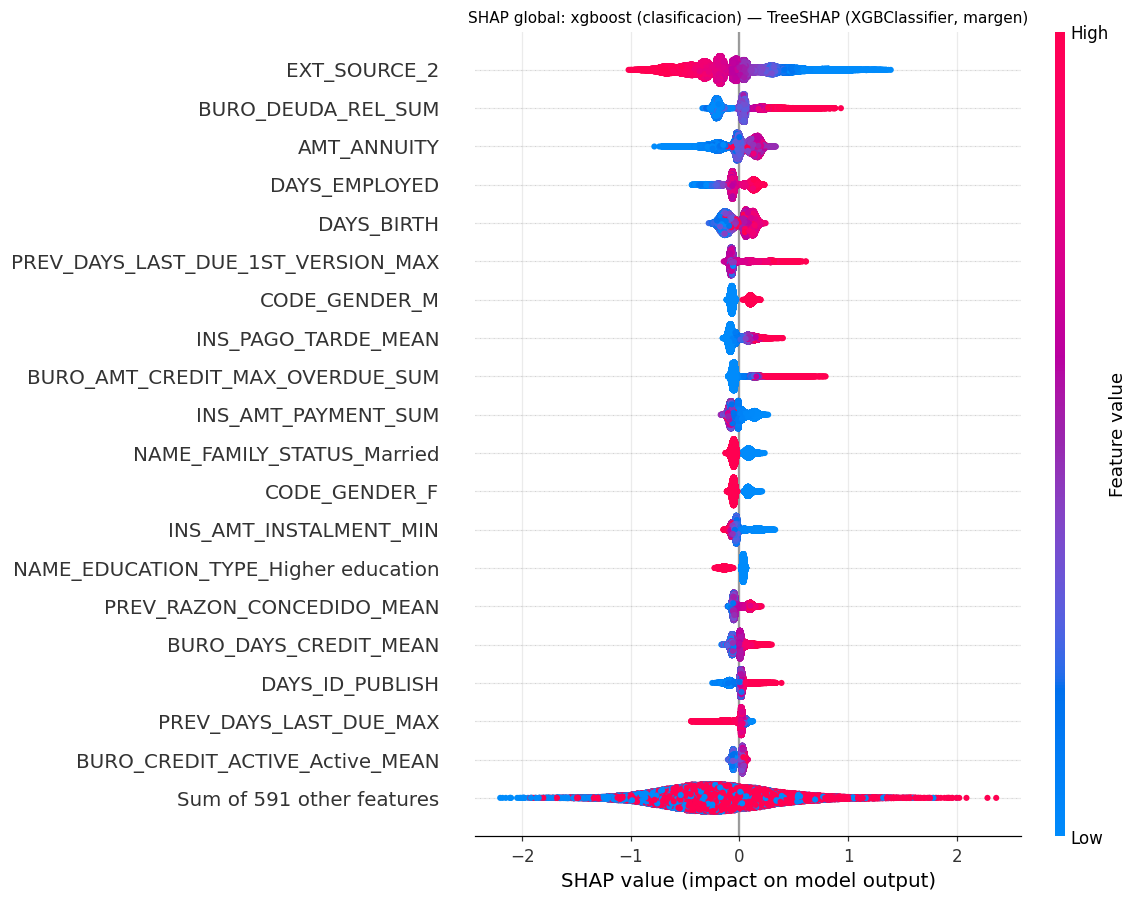

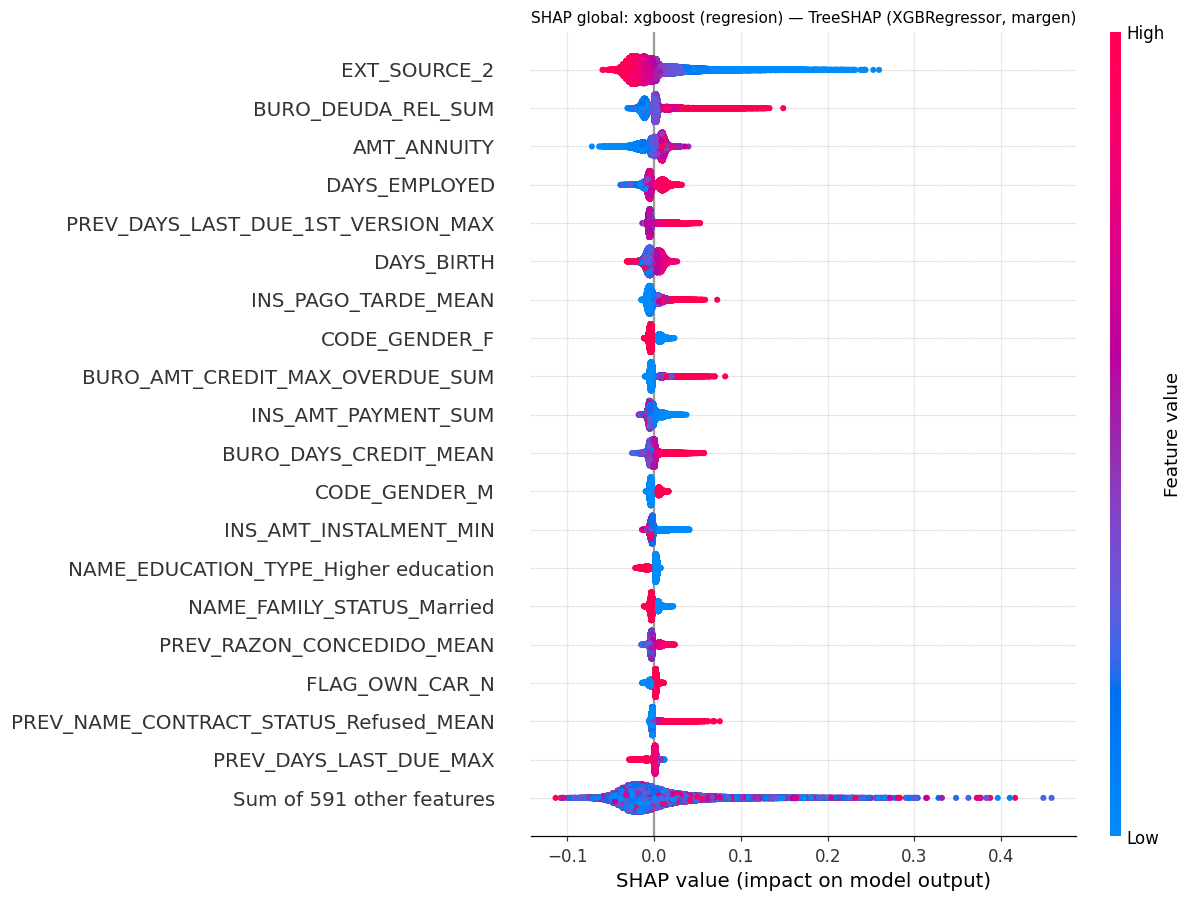

In [4]:
for (tarea, modelo), e in EXPL.items():
    plt.figure()
    shap.plots.beeswarm(e["sv"], max_display=20, show=False)
    plt.title(f"SHAP global: {modelo} ({tarea}) — {e['metodo']}", fontsize=10)
    graficos.guardar(plt.gcf(), f"08_shap_global_{tarea}_{modelo}")
    plt.show()
    imp = pd.Series(np.abs(e["sv"].values).mean(0), index=NOMBRES).sort_values(ascending=False)
    imp.head(30).to_csv(config.DIR_RESULTADOS / f"importancia_shap_{tarea}_{modelo}.csv")

**Lectura.** El ranking SHAP coincide con lo que el EDA estableció, con una ausencia que lo explica
casi todo. `EXT_SOURCE_2` es, con diferencia, la variable más influyente en los dos modelos XGBoost
(clasificación y regresión producen prácticamente el mismo ranking), con un efecto monótono: valores
bajos del puntaje externo elevan el riesgo. Le siguen variables de historial que la Fase 3 identificó
—la deuda relativa en la central de riesgo (`BURO_DEUDA_REL_SUM`), la mora máxima reportada
(`BURO_AMT_CREDIT_MAX_OVERDUE_SUM`), los pagos tardíos de cuotas anteriores (`INS_PAGO_TARDE_MEAN`) y
las solicitudes rechazadas en el pasado— y las de `application` sobre capacidad de pago y perfil:
anualidad, antigüedad laboral, edad, sexo, estado civil y nivel educativo.

`EXT_SOURCE_1` y `EXT_SOURCE_3`, que el EDA situó entre las variables más asociadas con el objetivo,
no aparecen: el embudo de la Fase 3.5 las excluyó por cobertura insuficiente (43.6 % y 80.2 %,
por debajo del umbral de 85 % fijado a priori). Es probablemente la decisión del proyecto con mayor
coste predictivo, y se discute en las conclusiones.

Frente a la línea base logística, SHAP muestra lo que un modelo lineal no puede representar: una
misma variable aporta contribuciones distintas para valores parecidos (la dispersión vertical de
cada fila del gráfico, visible en `DAYS_BIRTH`, `DAYS_EMPLOYED` o `AMT_ANNUITY`), lo que indica
interacciones, y el bloque de las 591 variables restantes suma contribuciones de hasta ±2 en el
margen: buena parte de la señal está repartida en muchas variables individualmente débiles.

## 3. Interpretabilidad local

Dos solicitantes que **sí incumplieron**: el que el modelo identificó con mayor puntaje (acierto claro)
y el que recibió el menor puntaje (el error más grave: un incumplidor tratado como el cliente más
seguro). El gráfico de cascada parte del valor base (predicción media) y suma la contribución de cada
variable hasta la predicción de esa observación, lo que ilustra la propiedad de eficiencia.

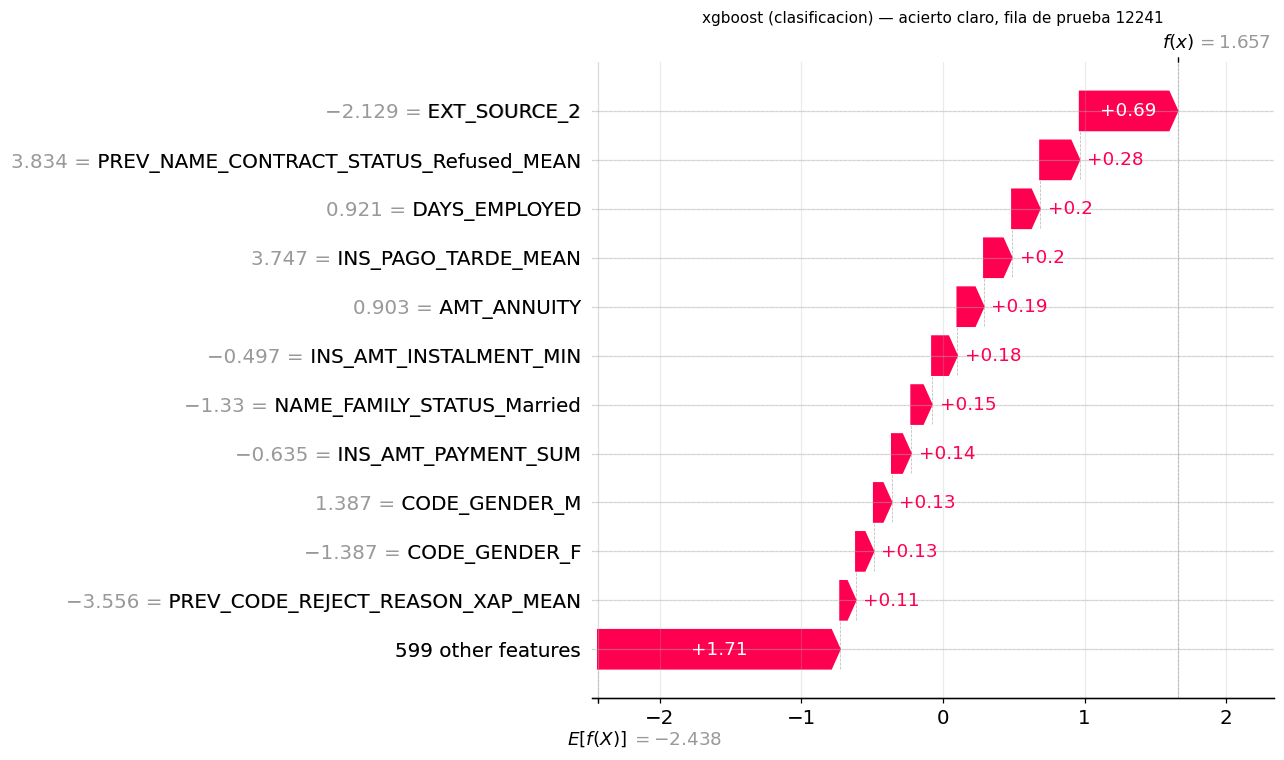

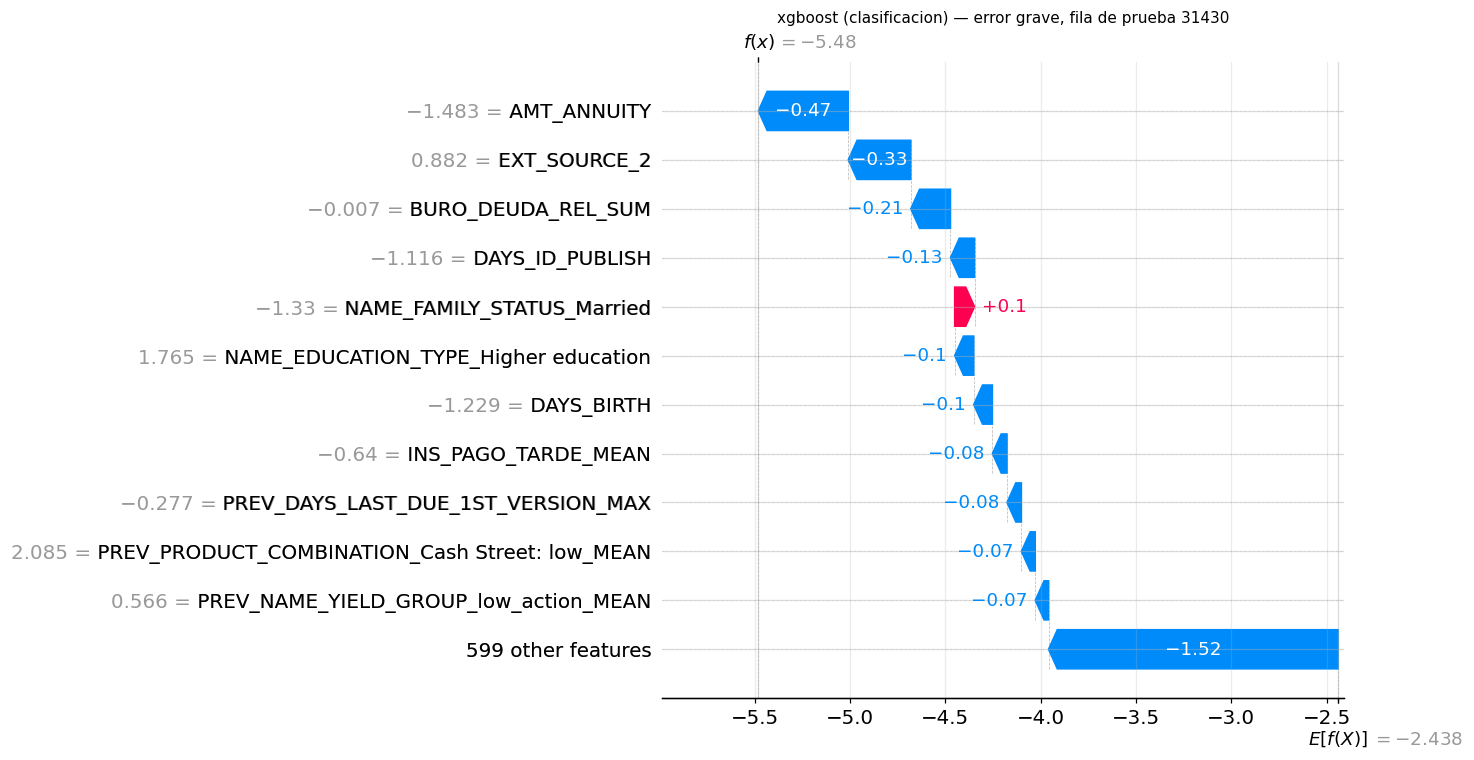

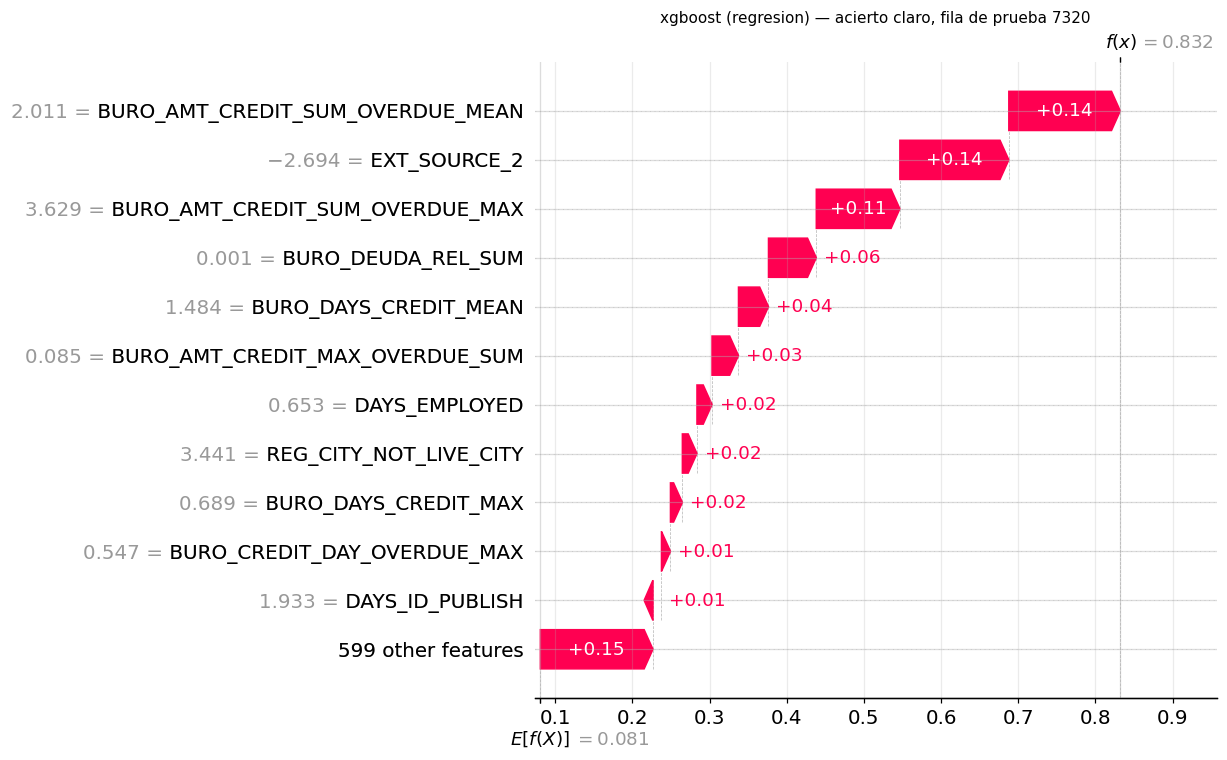

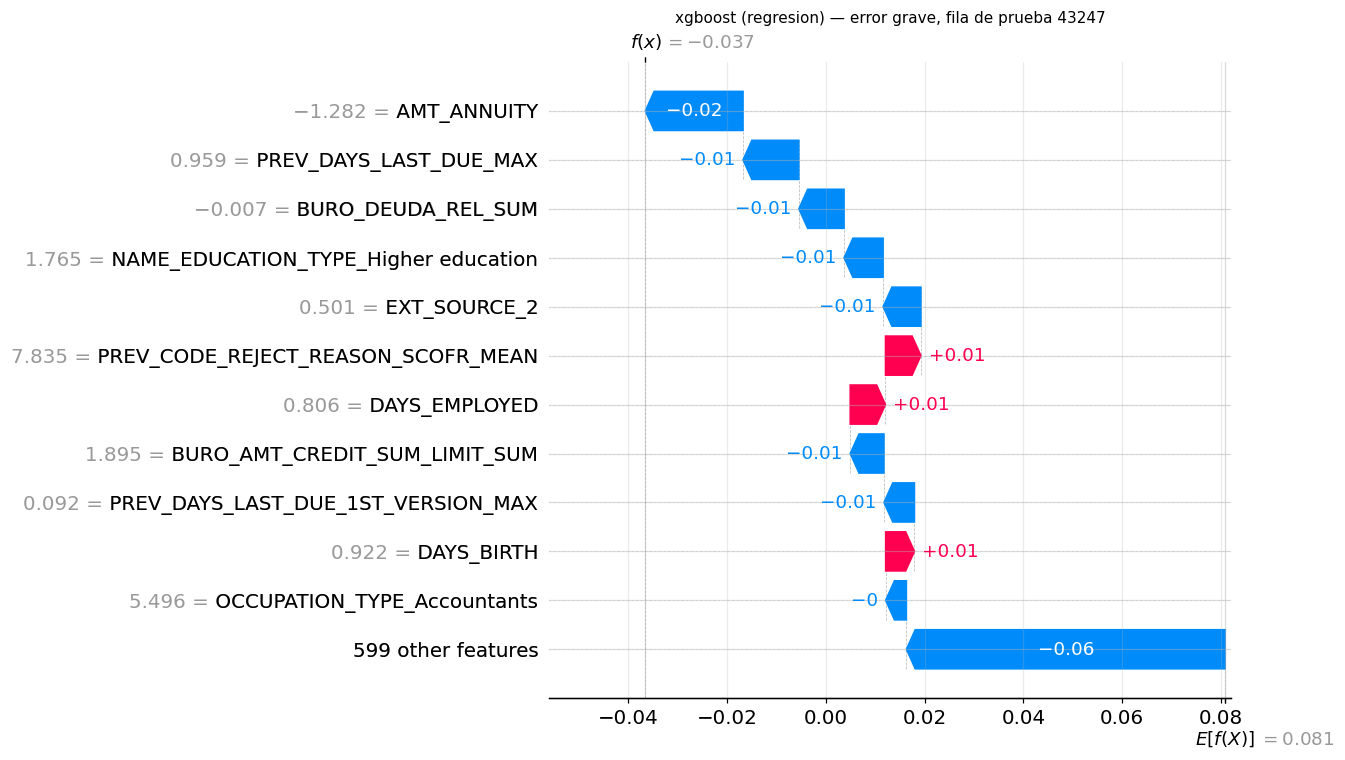

In [5]:
for (tarea, modelo), e in EXPL.items():
    pos = {f: i for i, f in enumerate(e["idx"])}
    for etiqueta, fila in zip(("acierto claro", "error grave"), e["loc"]):
        plt.figure()
        shap.plots.waterfall(e["sv"][pos[fila]], max_display=12, show=False)
        plt.title(f"{modelo} ({tarea}) — {etiqueta}, fila de prueba {fila}", fontsize=10)
        graficos.guardar(plt.gcf(), f"08_shap_local_{tarea}_{modelo}_{etiqueta.split()[0]}")
        plt.show()

**Lectura.** Los dos casos son incumplidores reales. En el **acierto claro** (fila de prueba
12241; margen 1.66 frente a una base de −2.44) casi todas las contribuciones empujan hacia el riesgo:
un `EXT_SOURCE_2` muy bajo (−2.1 desviaciones estándar) aporta +0.69 por sí solo, y se suman una alta
proporción de solicitudes rechazadas en el pasado (+0.28), poca antigüedad laboral (+0.20), pagos
tardíos frecuentes en cuotas anteriores (+0.20) y la anualidad (+0.19). En el **error grave** (fila
31430; margen −5.48, el menor entre los incumplidores) ocurre lo contrario: anualidad baja (−0.47),
`EXT_SOURCE_2` alto (−0.33), deuda relativa en la central cercana a la media (−0.21), educación
superior y mayor edad (−0.10 cada una). Es el perfil de un cliente de bajo riesgo, y ninguna de sus
variables anticipaba el incumplimiento: con la información disponible el modelo no tenía cómo
detectarlo. Ese es el límite irreducible de cualquier modelo sobre estos datos, y la razón por la
que un AUC de 0.77 deja una fracción de incumplidores con puntajes de cliente seguro.

## 4. SHAP frente a LIME en XGBoost

**LIME** (Ribeiro et al., 2016) explica una predicción ajustando un modelo lineal ponderado a
predicciones del modelo sobre perturbaciones de la observación; los pesos del modelo lineal son la
explicación. Diferencias metodológicas con SHAP:

| | SHAP (TreeSHAP) | LIME |
|---|---|---|
| Fundamento | Valores de Shapley: única atribución con eficiencia, simetría, aditividad y dummy | Aproximación lineal local, sin garantías axiomáticas |
| Exactitud | Exacto para árboles | Depende del muestreo, del núcleo de proximidad y de la discretización |
| Estabilidad | Determinista | Varía con la semilla y el número de muestras |
| Suma de contribuciones | Igual a predicción − base | No tiene por qué |
| Qué explica | Contribución frente al valor esperado del modelo | Comportamiento del modelo en un vecindario de la observación |

**Cuándo divergen.** Con variables muy correlacionadas (en este conjunto hay pares con |r| > 0.9 que
sobrevivieron al embudo), LIME perturba cada variable por separado y genera puntos fuera de la
distribución de los datos, donde el modelo puede comportarse de forma arbitraria; SHAP reparte el
efecto entre las correlacionadas. Divergen también con interacciones fuertes (un modelo lineal local
no las representa) y cerca de umbrales de los árboles, donde la función es escalonada y el ajuste
lineal depende del ancho del vecindario.

Se comparan las 10 variables principales de ambas explicaciones para los dos casos locales de XGBoost.

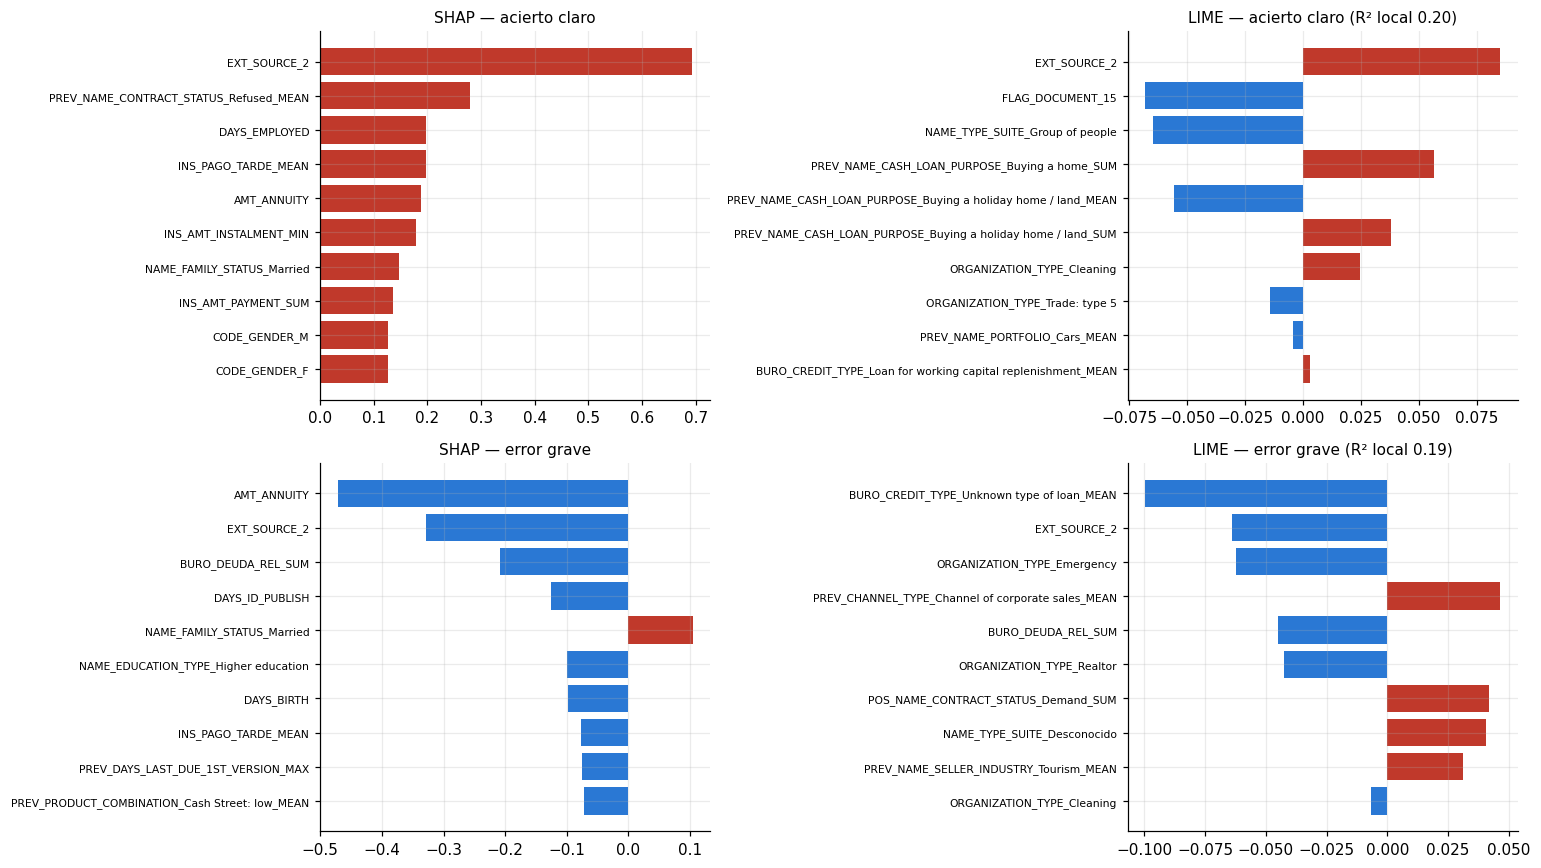

caso,variables_en_comun_top10,spearman_|peso|_union,signo_coincide_en_comunes
acierto claro,1,-0.547,1.000
error grave,2,-0.393,1.000


In [6]:
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
clave_xgb = ("clasificacion", "xgboost")
if clave_xgb in EXPL:
    est_xgb = fin.cargar_modelo(*clave_xgb)
    # LIME entrega matrices de numpy (CPU); predecir en la CPU da las mismas
    # probabilidades y evita copiar cada lote a la GPU.
    est_xgb.set_params(device="cpu")
    fondo_lime = X_fondo
    explicador_lime = LimeTabularExplainer(fondo_lime, feature_names=NOMBRES,
                                           class_names=["cumple", "incumple"], mode="classification",
                                           discretize_continuous=True, random_state=config.SEMILLA)
    e = EXPL[clave_xgb]
    pos = {f: i for i, f in enumerate(e["idx"])}
    filas_cmp = []
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for k, (etiqueta, fila) in enumerate(zip(("acierto claro", "error grave"), e["loc"])):
        le = explicador_lime.explain_instance(X_te[fila], est_xgb.predict_proba, num_features=10,
                                              num_samples=500 if config.MODO_PRUEBA else 5000)
        lime_w = pd.Series({NOMBRES[i]: w for i, w in le.as_map()[1]})
        shap_v = pd.Series(e["sv"].values[pos[fila]], index=NOMBRES)
        top_shap = shap_v.abs().sort_values(ascending=False).head(10).index
        comun = set(top_shap) & set(lime_w.index)
        union = list(set(top_shap) | set(lime_w.index))
        rho = spearmanr(shap_v[union].abs(), lime_w.reindex(union).fillna(0).abs()).correlation
        filas_cmp.append({"caso": etiqueta, "variables_en_comun_top10": len(comun),
                          "spearman_|peso|_union": rho,
                          "signo_coincide_en_comunes": float(np.mean([np.sign(shap_v[c]) == np.sign(lime_w[c])
                                                                      for c in comun])) if comun else np.nan})
        s = shap_v[top_shap][::-1]
        axes[k, 0].barh(s.index, s.values, color=["#c0392b" if v > 0 else "#2a78d4" for v in s.values])
        axes[k, 0].set_title(f"SHAP — {etiqueta}", fontsize=10)
        l = lime_w.sort_values(key=np.abs)
        axes[k, 1].barh(l.index, l.values, color=["#c0392b" if v > 0 else "#2a78d4" for v in l.values])
        axes[k, 1].set_title(f"LIME — {etiqueta} (R² local {le.score:.2f})", fontsize=10)
        for a in axes[k]:
            a.tick_params(axis="y", labelsize=7)
    fig.tight_layout()
    graficos.guardar(fig, "08_shap_vs_lime")
    plt.show()
    display(pd.DataFrame(filas_cmp).style.format(precision=3).hide(axis="index"))

**Lectura.** SHAP y LIME coinciden poco. Comparten 1 de las 10 variables principales en el acierto
claro y 2 en el error grave (`EXT_SOURCE_2` en ambos casos y `BURO_DEUDA_REL_SUM` en el segundo),
siempre con el mismo signo, pero la correlación de Spearman entre las magnitudes de la unión es
negativa (−0.55 y −0.39). El R² del modelo lineal local de LIME es 0.20 y 0.19: la aproximación
explica una quinta parte del comportamiento del modelo en el vecindario, de modo que sus pesos no son
fiables. El patrón de las diferencias apunta al escenario de perturbaciones fuera de la distribución
descrito arriba: el top de LIME está dominado por indicadoras de categorías raras
(`FLAG_DOCUMENT_15`, tipos de organización, propósitos de préstamos anteriores como "Buying a holiday
home / land") que, al perturbarse de forma independiente, generan combinaciones inexistentes en los
datos, donde los árboles responden de forma arbitraria. Para este modelo, SHAP —exacto para árboles y
determinista— es la explicación a usar; LIME sirve como contraste, no como sustituto.